In [1]:
import sys
from pathlib import Path

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = CURRENT
if not (PROJECT_ROOT / "SEConformer").exists():
    for parent in [CURRENT, *CURRENT.parents]:
        if (parent / "SEConformer").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
print("Projeto:", PROJECT_ROOT)
print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.is_available())


Projeto: C:\Users\franc\OneDrive\Desktop\Breast Cancer
Torch: 2.6.0+cu124
CUDA: 12.4
GPU: True


In [2]:
from SEConformer import DEVICE, build_inbreast_csv, make_run_dirs, train_inbreast_holdout

INBREAST_CSV_SOURCE = PROJECT_ROOT / "BrestCancer Datasets" / "INBreast" / "INbreast" / "INbreast.csv"
INBREAST_DICOM_DIR = PROJECT_ROOT / "BrestCancer Datasets" / "INBreast" / "INbreast" / "AllDICOMs"
INBREAST_FOLDS_CSV = PROJECT_ROOT / "SEConformer" / "inbreast_birads_folds.csv"

print("Device:", DEVICE)
print("Dataset:", INBREAST_CSV_SOURCE)


Device: cuda
Dataset: C:\Users\franc\OneDrive\Desktop\Breast Cancer\BrestCancer Datasets\INBreast\INbreast\INbreast.csv


In [3]:
df = build_inbreast_csv(
    inbreast_csv_path=str(INBREAST_CSV_SOURCE),
    dicom_dir=str(INBREAST_DICOM_DIR),
    out_csv=str(INBREAST_FOLDS_CSV),
    mode="multiclass",
    n_splits=5,
    random_state=42,
)
print("Total imagens:", len(df))
df.head()


CSV criado com sucesso! C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\inbreast_birads_folds.csv
Total imagens: 410


,image_path,label,birads,class_name,fold
0,C:\Users\franc\OneDrive\Desktop\Breast Cancer\...,0,1,birads_1,2
1,C:\Users\franc\OneDrive\Desktop\Breast Cancer\...,2,3,birads_3,0
2,C:\Users\franc\OneDrive\Desktop\Breast Cancer\...,0,1,birads_1,1
3,C:\Users\franc\OneDrive\Desktop\Breast Cancer\...,2,3,birads_3,0
4,C:\Users\franc\OneDrive\Desktop\Breast Cancer\...,4,5,birads_5,4


100%|██████████| 21/21 [01:56<00:00,  5.56s/it]



Epoch 0 Loss: 1.3750
RESULTADOS:
accuracy: 0.0366
precision_macro: 0.0061
recall_macro: 0.1667
f1_macro: 0.0118
auc_macro_ovr: 0.5173
Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\epoch_0_metrics.json


100%|██████████| 21/21 [01:31<00:00,  4.37s/it]



Epoch 1 Loss: 1.2828
RESULTADOS:
accuracy: 0.0488
precision_macro: 0.0157
recall_macro: 0.1944
f1_macro: 0.0278
auc_macro_ovr: 0.6238
Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\epoch_1_metrics.json


100%|██████████| 21/21 [01:23<00:00,  3.99s/it]



Epoch 2 Loss: 1.2280
RESULTADOS:
accuracy: 0.0732
precision_macro: 0.0472
recall_macro: 0.1944
f1_macro: 0.0751
auc_macro_ovr: 0.5539
Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\epoch_2_metrics.json


100%|██████████| 21/21 [01:24<00:00,  4.04s/it]



Epoch 3 Loss: 1.1706
RESULTADOS:
accuracy: 0.0976
precision_macro: 0.2095
recall_macro: 0.2347
f1_macro: 0.1159
auc_macro_ovr: 0.5882
Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\epoch_3_metrics.json


100%|██████████| 21/21 [01:25<00:00,  4.07s/it]



Epoch 4 Loss: 1.1700
RESULTADOS:
accuracy: 0.1098
precision_macro: 0.3764
recall_macro: 0.2840
f1_macro: 0.1207
auc_macro_ovr: 0.5636
Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\epoch_4_metrics.json
RESULTADOS:
accuracy: 0.1098
precision_macro: 0.3764
recall_macro: 0.2840
f1_macro: 0.1207
auc_macro_ovr: 0.5636
Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\plots\final_confusion_matrix.png


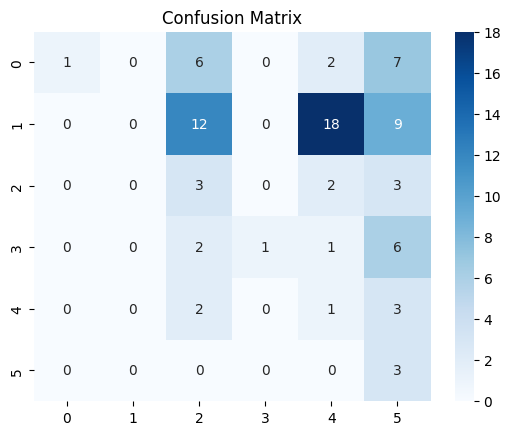

Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\final_metrics.json


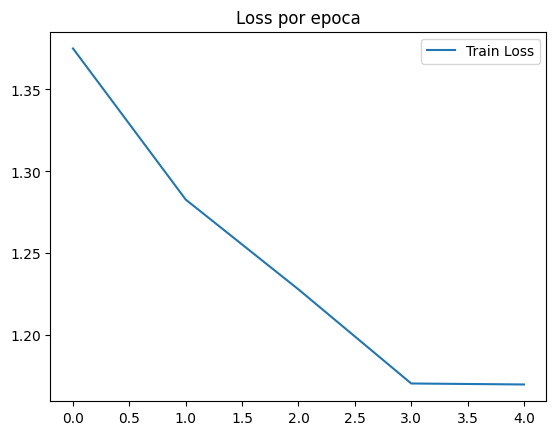

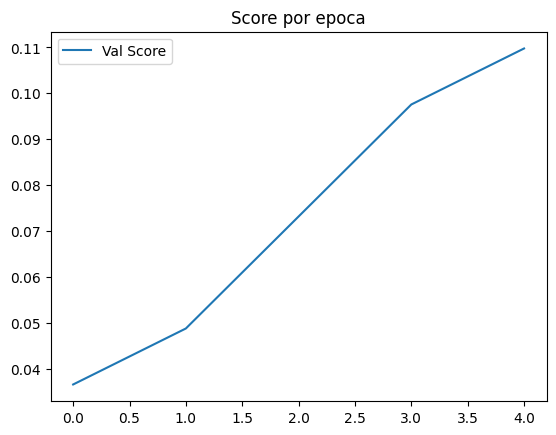

Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\history.csv
Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\models\seconformer_inbreast.pt
Salvo: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136\final_metrics.json
Run: C:\Users\franc\OneDrive\Desktop\Breast Cancer\SEConformer\runs\seconformer_inbreast_holdout_20260519-150136


{'accuracy': 0.10975609756097561,
 'precision_macro': 0.37640681003584225,
 'recall_macro': 0.28402777777777777,
 'f1_macro': 0.12073677956030898,
 'auc_macro_ovr': 0.5635652137230541}

In [4]:
run_dirs = make_run_dirs(run_prefix="seconformer_inbreast_holdout")
model, run_dirs, metrics = train_inbreast_holdout(
    csv_path=str(INBREAST_FOLDS_CSV),
    val_fraction=0.2,
    epochs=5,
    batch_size=16,
    run_dirs=run_dirs,
    img_size=224,
    balance=True,
)

print("Run:", run_dirs["out_dir"])
metrics
